In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
import warnings

In [2]:
name = ['SK1-052 9.6 kPa-650C', 'TCM2-027 9.6 kPa-650C', 'TCM2-071 9.6 kPa-650C']
number = ['45', '22', '16']

exp = {}

for sname, anum in zip(name, number):
    df = pd.read_excel('230319 TCM Al content 9.6 kPa.xlsx', sheet_name=sname)
    df.columns = df.columns.str.strip()

    time_col, total_al_col, al_col, error_col, rate_col = 'Time / h', 'Total Al / uc', 'Al/uc', 'Error Al/uc', 'Rate / mol ucˆ-1 hˆ-1'
    si_al_col = 'Si/Al'

    df_clean = df[[time_col, total_al_col, al_col, error_col, rate_col]].dropna()

    time_data      = pd.to_numeric(df_clean[time_col], errors='coerce').to_numpy()
    total_al_data  = pd.to_numeric(df_clean[total_al_col], errors='coerce').to_numpy()
    al_f_data   = pd.to_numeric(df_clean[al_col], errors='coerce').to_numpy()
    errors_data    = pd.to_numeric(df_clean[error_col], errors='coerce').to_numpy()
    rate_data      = pd.to_numeric(df_clean[rate_col], errors='coerce').to_numpy()

    exp[anum] = {
        'time':  time_data,
        'Al_f':  al_f_data,
        'Al_tot': total_al_data[0],
        'error': errors_data,
        'rate':  rate_data,
    }

exp

{'45': {'time': array([ 0,  2,  4,  8, 16, 32, 64]),
  'Al_f': array([0.57789749, 0.44603443, 0.35156755, 0.30445075, 0.19023879,
         0.11902728, 0.06838535]),
  'Al_tot': np.float64(0.7539061007838296),
  'error': array([0.0693477 , 0.05352413, 0.04218811, 0.03653409, 0.02282866,
         0.01428327, 0.00820624]),
  'rate': array([0.08068456, 0.0485394 , 0.03237917, 0.01733956, 0.00734544,
         0.00254685, 0.00076691])},
 '22': {'time': array([ 0. ,  1. ,  1.5,  2. ,  4. ,  6. ,  8. , 12. , 16. , 22. ]),
  'Al_f': array([1.06353382, 0.76429995, 0.66095391, 0.62854063, 0.4747066 ,
         0.37568761, 0.30533399, 0.22265274, 0.1805682 , 0.14812072]),
  'Al_tot': np.float64(1.4662980027207297),
  'error': array([0.12762406, 0.09171599, 0.07931447, 0.07542488, 0.05696479,
         0.04508251, 0.03664008, 0.02671833, 0.02166818, 0.01777449]),
  'rate': array([0.4178794 , 0.20170608, 0.15305055, 0.12053673, 0.05845077,
         0.03500953, 0.02353397, 0.0129365 , 0.00827638, 0.004

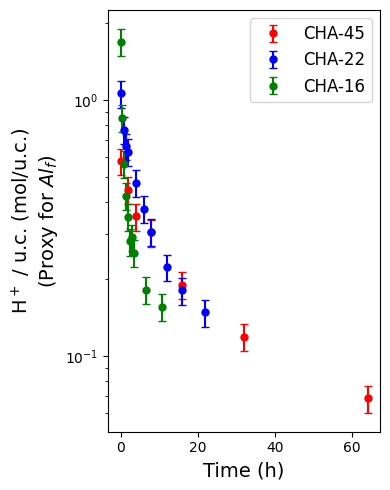

In [3]:
name_list = ['CHA-45', 'CHA-22', 'CHA-16']
colors = {'45': 'r', '22': 'b', '16': 'g'}

fig, ax = plt.subplots(figsize=(4, 5))

for idx, key in enumerate(['45','22','16']):
    ax.errorbar(
        exp[key]['time'],
        exp[key]['Al_f'],
        yerr=exp[key]['error'],
        fmt='o',
        markersize=5,
        capsize=3,
        linewidth=1.5,
        label=name_list[idx],
        color = colors[key]
    )

ax.set_xlabel('Time (h)', fontsize=14)
ax.set_ylabel('H$^+$ / u.c. (mol/u.c.)\n(Proxy for $Al_f$)', fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

In [4]:
def model(t, y, params):
    k1, k_1, k2 = params
    Al_f, Al_ex, Al_ex2, vac = y
    r1  = k1 * Al_f
    r_1 = k_1 * Al_ex * vac
    r2  = k2 * Al_ex**2
    return [
        -r1 + r_1,
        r1 - r_1 - 2*r2,
        r2,
        r1 - r_1
    ]

def simulate_model(params, sial_ratio):
    exp_data = data[sial_ratio]
    time_span = exp_data['time']
    y0 = [exp_data['Al_f'][0], 0, 0, 0]
    try:
        sol = solve_ivp(
            model,
            t_span=(time_span[0], time_span[-1]),
            y0=y0,
            args=(params,),
            t_eval=time_span,
            method='Radau',
            rtol=1e-8, atol=1e-10,
            dense_output=True
        )
        if not sol.success or np.any(np.isnan(sol.y)):
            return None, None, None
        return sol.y[0], sol.y[1], sol.y[2]
    except Exception:
        return None, None, None

def simulate_model_cont(params, sial_ratio):
    exp_data = data[sial_ratio]
    time_span = exp_data['time']
    t=np.linspace(0,exp['45']['time'][-1],100)
    y0 = [exp_data['Al_f'][0], 0, 0, 0]
    try:
        sol = solve_ivp(
            model,
            t_span=(0, t[-1]),
            y0=y0,
            args=(params,),
            t_eval=t,
            method='Radau',
            rtol=1e-8, atol=1e-10,
            dense_output=True
        )
        if not sol.success or np.any(np.isnan(sol.y)):
            return None, None, None
        return sol.y[0]
    except Exception:
        return None, None, None

def objective(params):
    """Mean relative squared error across all Si/Al ratios."""
    k1, k_1, k2 = params
    if any(p <= 0 for p in params):
        return 1e10
    total_error = 0.0
    for sial in ['45', '22', '16']:
        Al_f_pred, _, _ = simulate_model(params, sial)
        if Al_f_pred is None:
            return 1e10
        Al_f_exp = data[sial]['Al_f']
        # rel_err = np.mean(((Al_f_pred - Al_f_exp) / Al_f_exp)**2)
        # rel_err = np.mean((np.log(Al_f_pred) - np.log(Al_f_exp))**2)
        rel_err = np.sum((Al_f_pred - Al_f_exp)**2)
        total_error += rel_err
    total_error = total_error/3
    return total_error

In [5]:
def callback(xk, convergence):
    fval = objective_log(xk)
    step = len(history) + 1
    history.append({
        "step": len(history) + 1,
        "fun": fval,
        "x": 10.0 ** xk.copy(),
        "convergence": convergence
    })
    print(f"step={step:4d}  fun={fval:12.6e}  x={10**xk}  conv={convergence:.3e}")

In [6]:
from scipy.optimize import differential_evolution
import numpy as np

history = []
# ── data alias (your existing dict) ──────────────────────────────────────────
data = exp   # make sure 'exp' is already built

# ── bounds for [k1, k_1, k2] in log-space ────────────────────────────────────
# Working in log-space prevents negative params and helps when
# rate constants span several orders of magnitude
LOG_BOUNDS = [(-6, 5), (-6, 5), (-6, 2)]   # i.e. 1e-6 … 1e2 for each k

def objective_log(log_params):
    """
    Optimise in log-space so DE explores multiplicative space evenly.
    Residuals are also log-space (relative error) — consistent with
    the advice from your earlier fitting discussion.
    """
    params = 10.0 ** np.array(log_params)   # back to linear scale
    total_error = 0.0

    for sial in ['45', '22', '16']:
        Al_f_pred, _, _ = simulate_model(params, sial)

        if Al_f_pred is None:
            return 1e10

        Al_f_exp = data[sial]['Al_f']

        # guard against zeros before log
        Al_f_pred = np.maximum(Al_f_pred, 1e-12)
        Al_f_exp  = np.maximum(Al_f_exp,  1e-12)

        total_error += np.mean((np.log(Al_f_pred) - np.log(Al_f_exp)) ** 2)

    return total_error / 3


result = differential_evolution(
    objective_log,
    bounds=LOG_BOUNDS,
    seed=42,
    maxiter=1000,
    popsize=15,
    workers=1,
    disp=True,
    tol = 1e-12,
    callback=callback
)

differential_evolution step 1: f(x)= 0.41515731211406653
step=   1  fun=4.151573e-01  x=[1.74891098e+03 1.72853212e+03 5.96571952e-02]  conv=2.104e-13
differential_evolution step 2: f(x)= 0.40856969115555053
step=   2  fun=4.085697e-01  x=[0.40994341 0.37438729 0.05304773]  conv=4.462e-13
differential_evolution step 3: f(x)= 0.4043914691690899
step=   3  fun=4.043915e-01  x=[6.85630613 8.07556838 0.13517121]  conv=2.179e-12
differential_evolution step 4: f(x)= 0.4043914691690899
step=   4  fun=4.043915e-01  x=[6.85630613 8.07556838 0.13517121]  conv=2.072e-12
differential_evolution step 5: f(x)= 0.4043914691690899
step=   5  fun=4.043915e-01  x=[6.85630613 8.07556838 0.13517121]  conv=2.053e-12
differential_evolution step 6: f(x)= 0.3953932626715369
step=   6  fun=3.953933e-01  x=[29.7532227  70.851628    0.35625282]  conv=2.242e-12
differential_evolution step 7: f(x)= 0.3953932626715369
step=   7  fun=3.953933e-01  x=[29.7532227  70.851628    0.35625282]  conv=2.519e-12
differential_e

Text(0, 0.5, 'Sum of squared errors (SSE)')

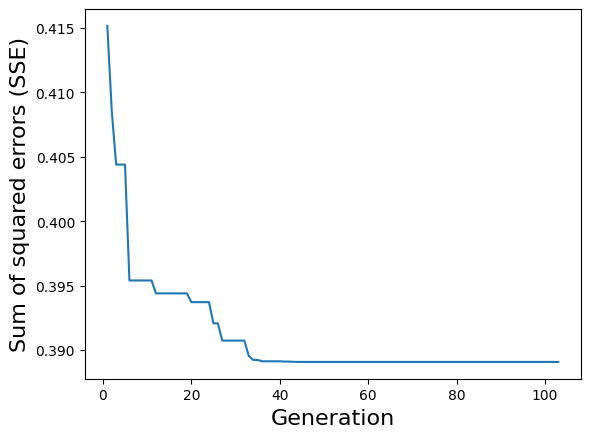

In [7]:
steps = [h["step"] for h in history]
fvals = [h["fun"] for h in history]
plt.plot(steps,fvals)
plt.xlabel("Generation",fontsize=16)
plt.ylabel("Sum of squared errors (SSE)",fontsize=16)

In [8]:
# ── unpack results ────────────────────────────────────────────────────────────
k1_opt, k_1_opt, k2_opt = 10.0 ** result.x

print(f"\n{'='*50}")
print(f"Converged: {result.success}  |  Message: {result.message}")
print(f"Final log-space residual : {result.fun:.6e}")
print(f"{'='*50}")
print(f"k1  = {k1_opt:.6e}")
print(f"k_1 = {k_1_opt:.6e}")
print(f"k2  = {k2_opt:.6e}")

params_opt = np.array([k1_opt, k_1_opt, k2_opt])


Converged: True  |  Message: Optimization terminated successfully.
Final log-space residual : 3.890688e-01
k1  = 5.222518e-01
k_1 = 3.616851e-01
k2  = 4.535391e-02


In [ ]:
!pip3 install tqdm

In [10]:
import emcee   # pip install emcee

def log_posterior(log_params):
    """Log-posterior = -0.5 * chi2 (uniform prior in log-space bounds)."""
    # check bounds
    for lp, (lo, hi) in zip(log_params, LOG_BOUNDS):
        if not (lo < lp < hi):
            return -np.inf
    return -0.5 * objective_log(log_params)

ndim     = 3
nwalkers = 32   # must be even and > 2*ndim

# ── initialize walkers around DE optimum ─────────────────────────────────────
x_opt   = result.x
p0      = x_opt + 1e-3 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

# burn-in
print("Burn-in...")
sampler.run_mcmc(p0, 500, progress=True)
sampler.reset()

# production
print("Production...")
sampler.run_mcmc(sampler.get_last_sample(), 2000, progress=True)

# ── extract samples ───────────────────────────────────────────────────────────
flat_samples = sampler.get_chain(discard=100, thin=10, flat=True)
samples_lin  = 10.0 ** flat_samples   # convert to linear space

# ── covariance & correlation ──────────────────────────────────────────────────
labels = ['k1', 'k_1', 'k2']
cov_mcmc  = np.cov(flat_samples.T)
corr_mcmc = np.corrcoef(flat_samples.T)

print("\nCorrelation matrix (MCMC):")
print(pd.DataFrame(corr_mcmc, index=labels, columns=labels).round(3))

# ── corner plot ───────────────────────────────────────────────────────────────
import corner   # pip install corner
fig = corner.corner(
    samples_lin,
    labels        = labels,
    quantiles     = [0.16, 0.5, 0.84],
    show_titles   = True,
    title_fmt     = '.3e',
    smooth        = 1.0
)
plt.show()

# ── marginal uncertainties ────────────────────────────────────────────────────
for i, label in enumerate(labels):
    lo, med, hi = np.percentile(samples_lin[:, i], [16, 50, 84])
    print(f"{label}: {med:.3e}  +{hi-med:.3e}  -{med-lo:.3e}")

Burn-in...


You must install the tqdm library to use progress indicators with emcee


Production...


AttributeError: you must run the sampler with 'store == True' before accessing the results

In [127]:
import numdifftools as nd   # pip install numdifftools

# ── numerical Hessian at DE optimum (log-space params) ───────────────────────
x_opt = result.x   # log-space best params from DE

H = nd.Hessian(objective_log)(x_opt)
cov_log = np.linalg.inv(H)          # covariance in log-space
corr    = cov_log / np.outer(
              np.sqrt(np.diag(cov_log)),
              np.sqrt(np.diag(cov_log))
          )

labels = ['k1', 'k_1', 'k2']
print("Covariance matrix (log-space):")
print(pd.DataFrame(cov_log, index=labels, columns=labels))
print("\nCorrelation matrix:")
print(pd.DataFrame(corr, index=labels, columns=labels).round(3))

Covariance matrix (log-space):
           k1       k_1         k2
k1   1.623923  2.859502   2.557264
k_1  2.859502  7.227159   9.439879
k2   2.557264  9.439879  17.821159

Correlation matrix:
        k1    k_1     k2
k1   1.000  0.835  0.475
k_1  0.835  1.000  0.832
k2   0.475  0.832  1.000


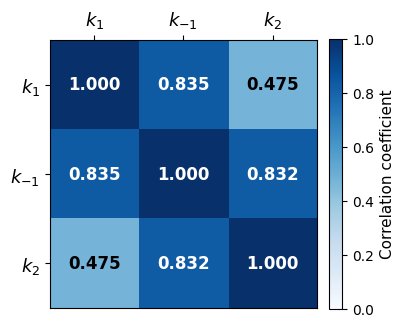

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

labels = ['$k_1$', '$k_{-1}$', '$k_2$']
corr = np.array([
    [1.000, 0.835, 0.475],
    [0.835, 1.000, 0.832],
    [0.475, 0.832, 1.000]
])

fig, ax = plt.subplots(figsize=(4, 3.5))

# ── heatmap ───────────────────────────────────────────────────────────────────
cmap = plt.cm.Blues
im = ax.imshow(corr, cmap=cmap, vmin=0, vmax=1)

# ── colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation coefficient', fontsize=11)
cbar.ax.tick_params(labelsize=10)

# ── axis labels ───────────────────────────────────────────────────────────────
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticklabels(labels, fontsize=13)
ax.xaxis.set_ticks_position('top')       # column labels on top
ax.xaxis.set_label_position('top')

# ── annotate each cell ────────────────────────────────────────────────────────
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr[i, j]
        # white text on dark cells, dark text on light cells
        text_color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}',
                ha='center', va='center',
                fontsize=12, color=text_color, fontweight='bold')

# # ── strength annotation (off-diagonal only) ───────────────────────────────────
# strength = {(0,1): 'strong', (1,0): 'strong',
#             (1,2): 'strong', (2,1): 'strong',
#             (0,2): 'moderate', (2,0): 'moderate'}

# for (i, j), label in strength.items():
#     ax.text(j, i + 0.28, label,
#             ha='center', va='center',
#             fontsize=7, color='white' if corr[i,j] > 0.6 else 'steelblue',
#             style='italic')

# ax.set_title('Correlation matrix — kinetic parameters', 
#              fontsize=11, pad=18, color='dimgray')

fig.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

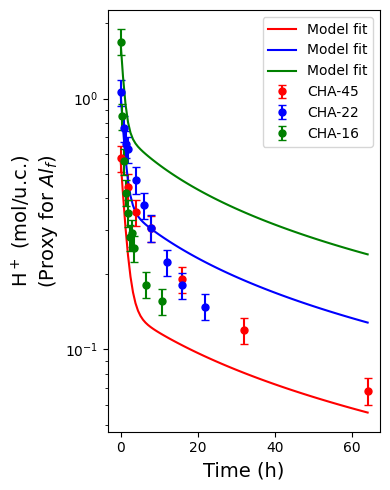

In [153]:
colors = {'45': 'r', '22': 'b', '16': 'g'}

pred = {}
fig, ax = plt.subplots(figsize=(4, 5))
for key in ['45','22','16']:
    plt.errorbar(
            exp[key]['time'],
            exp[key]['Al_f'],
            yerr=exp[key]['error'],
            fmt='o',
            markersize=5,
            capsize=3,
            linewidth=1.5,
            label=f'CHA-{key}',
            color = colors[key]
        )
    t=np.linspace(0,exp['45']['time'][-1],100)
    pred[key] = {}
    pred[key]['Al_f'] = simulate_model(params_opt,key)[0]
    plt.plot(t, simulate_model_cont(params_opt,key),color=colors[key], label='Model fit')
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel('H$^+$ (mol/u.c.)\n(Proxy for $Al_f$)', fontsize=14)
plt.yscale("log")
plt.legend(fontsize=10)
fig.tight_layout()
plt.show()

In [147]:
exp_alf

array([1.69087237, 0.8526778 , 0.56330568, 0.42220484, 0.35082315,
       0.28042553, 0.29164626, 0.25270177, 0.18128157, 0.15600338])

In [148]:
pred_alf

array([1.69087237, 1.31107909, 1.05358771, 0.89308918, 0.79655633,
       0.73817022, 0.70139986, 0.67662037, 0.60135065, 0.53420454])

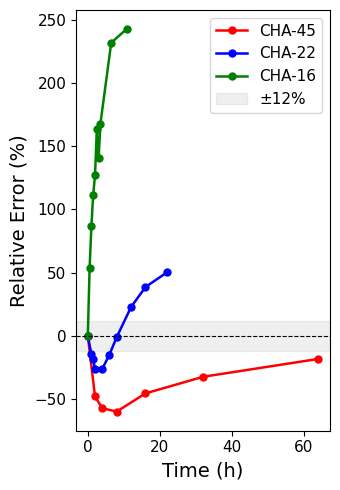

In [156]:
fig, ax = plt.subplots(figsize=(3.5, 5))

for sample in ['45', '22', '16']:
    exp_alf  = exp[sample]['Al_f']
    pred_alf = pred[sample]['Al_f']
    time     = exp[sample]['time']

    # Relative error (%) — skip t=0 to avoid division by zero
    rel_error = ((pred_alf - exp_alf) / exp_alf) * 100

    ax.plot(time, rel_error,
            marker='o',
            color=colors[sample],
            label=labels[sample],
            linewidth=1.8,
            markersize=5)

# Reference line at zero
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Experimental uncertainty band (±12%)
ax.axhspan(-12, 12, alpha=0.12, color='gray', label='±12%')

ax.set_xlabel('Time (h)', fontsize=14)
ax.set_ylabel('Relative Error (%)', fontsize=14)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()


In [118]:
def compute_errors(exp, pred, keys=['45', '22', '16']):
    results = {}
    for key in keys:
        y_true = np.array(exp[key]['Al_f'])
        y_pred = np.array(pred[key]['Al_f'])

        pct_err = (y_pred - y_true) / y_true * 100   # signed, in %

        mpe   = np.mean(pct_err)
        rmspe = np.sqrt(np.mean(pct_err ** 2))

        results[key] = {'MPE (%)': mpe, 'RMSPE (%)': rmspe}

        print(f"Si/Al = {key}:  MPE = {mpe:+.2f}%   RMSPE = {rmspe:.2f}%")

    # ── overall across all datasets ───────────────────────────────────────────
    all_pct_err = np.concatenate([
        ((np.array(pred[k]['Al_f']) - np.array(exp[k]['Al_f']))
         / np.array(exp[k]['Al_f']) * 100).ravel()   # ← .ravel() forces 1D
        for k in keys
    ])
    print(f"\nOverall:   MPE = {np.mean(all_pct_err):+.2f}%   "
          f"RMSPE = {np.sqrt(np.mean(all_pct_err**2)):.2f}%")

    return results

errors = compute_errors(exp, pred)

Si/Al = 45:  MPE = -15.77%   RMSPE = 75.30%
Si/Al = 22:  MPE = -6.64%   RMSPE = 69.57%
Si/Al = 16:  MPE = +66.69%   RMSPE = 148.45%

Overall:   MPE = +18.15%   RMSPE = 106.89%


In [122]:
df = pd.DataFrame([
    {"step": h["step"], "fun": h["fun"],
     "k1": h["x"][0], "k_1": h["x"][1], "k2": h["x"][2],
     "convergence": h["convergence"]}
    for h in history
])

threshold = df["fun"].quantile(0.10)
df_top10 = df[df["fun"] <= threshold].sort_values("fun").reset_index(drop=True)

In [123]:
df_top10

,step,fun,k1,k_1,k2,convergence
0,100,0.389069,0.522252,0.361685,0.045354,0.367527
1,101,0.389069,0.522252,0.361685,0.045354,0.410912
2,102,0.389069,0.522252,0.361685,0.045354,0.420594
3,103,0.389069,0.522252,0.361685,0.045354,1.295820
4,99,0.389069,0.522252,0.361684,0.045354,0.300597
5,98,0.389069,0.522252,0.361685,0.045354,0.309218
6,95,0.389069,0.522251,0.361684,0.045354,0.055981
7,96,0.389069,0.522251,0.361684,0.045354,0.069692
8,97,0.389069,0.522251,0.361684,0.045354,0.071951
9,93,0.389069,0.522252,0.361686,0.045354,0.052713


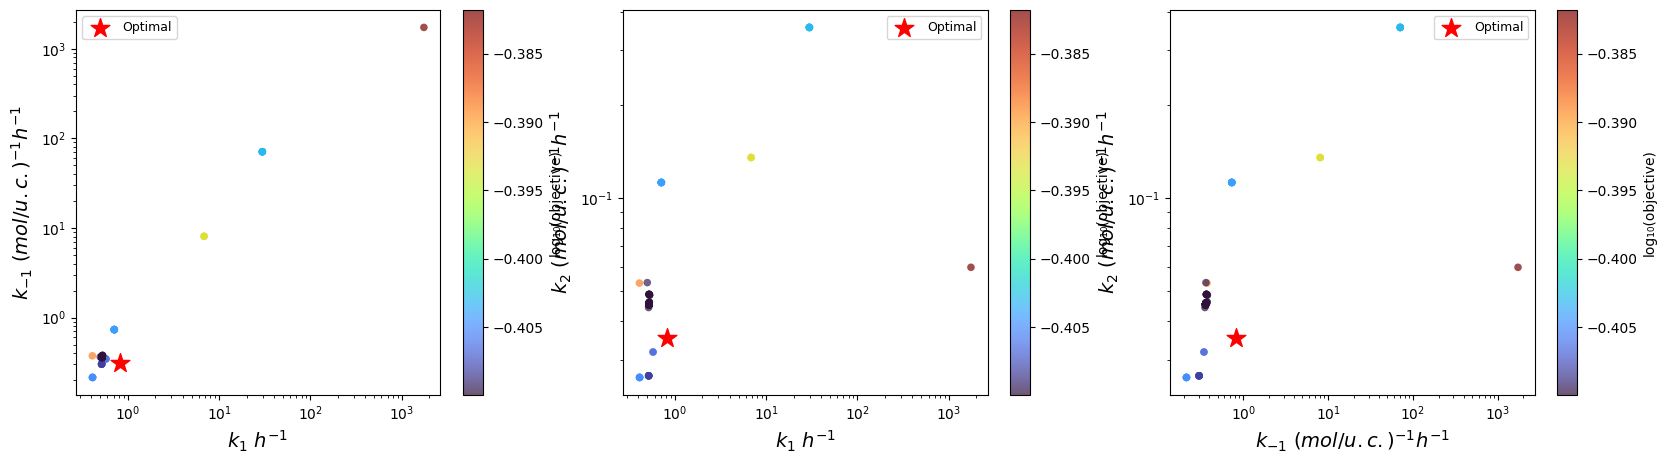

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

thr = np.quantile(history['y'], 0.10)                  # 10th percentile (small y)
mask = history['y'] <= thr
y_cut = np.array([h["fun"] for h in history])
X_cut = np.array([h["x"] for h in history])

# k1 vs k_1 colored by objective
ax_k1k_1 = axes[0]
sc = ax_k1k_1.scatter(X_cut[:, 0], X_cut[:, 1], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k_1.scatter(best_params[0], best_params[1],
                  color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k_1.set_xscale('log'); ax_k1k_1.set_yscale('log')
ax_k1k_1.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
ax_k1k_1.set_ylabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc, ax=ax_k1k_1, label='log₁₀(objective)')
# ax_k1k_1.legend(fontsize=9)

# k1 vs k2
ax_k1k2 = axes[1]
sc2 = ax_k1k2.scatter(X_cut[:, 0], X_cut[:, 2], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k2.scatter(best_params[0], best_params[2],
                 color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k2.set_xscale('log'); ax_k1k2.set_yscale('log')
ax_k1k2.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
ax_k1k2.set_ylabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc2, ax=ax_k1k2, label='log₁₀(objective)')
# ax_k1k2.legend(fontsize=9)

# k_1 vs k2
ax_k1k2 = axes[2]
sc2 = ax_k1k2.scatter(X_cut[:, 1], X_cut[:, 2], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k2.scatter(best_params[0], best_params[2],
                 color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k2.set_xscale('log'); ax_k1k2.set_yscale('log')
ax_k1k2.set_xlabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
ax_k1k2.set_ylabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc2, ax=ax_k1k2, label='log₁₀(objective)')
# ax_k1k2.legend(fontsize=9)

In [14]:
from scipy.optimize._differentialevolution import DifferentialEvolutionSolver

# ── storage ───────────────────────────────────────────────────────────────────
history = {
    'iteration':  [],
    'candidates': [],   # all population members (popsize × 3), log-space
    'obj_values': [],   # objective for each candidate
    'best_params': [],  # best k1, k_1, k2 (linear scale) per iteration
    'best_obj':    [],  # best objective per iteration
}

# ── build solver (same kwargs as differential_evolution) ─────────────────────
solver = DifferentialEvolutionSolver(
    objective_log,
    bounds=LOG_BOUNDS,
    rng=42,
    maxiter=500,
    popsize=15,
    workers=1,
    disp=True
)

# ── iterate manually ──────────────────────────────────────────────────────────
with solver:
    for i in range(solver.maxiter):
        try:
            xk, convergence = next(solver)   # ← unpack tuple directly
        except StopIteration:
            break

        pop        = solver.population.copy()
        pop_lin    = 10.0 ** pop
        pop_energy = solver.population_energies.copy()

        best_lin = 10.0 ** xk

        history['iteration'].append(i)
        history['candidates'].append(pop_lin)
        history['obj_values'].append(pop_energy)
        history['best_params'].append(best_lin)
        history['best_obj'].append(solver.population_energies.min())

        if i % 50 == 0:
            print(f"Iter {i:4d} | best obj = {solver.population_energies.min():.4e} | "
                  f"k1={best_lin[0]:.3e}, k_1={best_lin[1]:.3e}, k2={best_lin[2]:.3e}")

        # manual convergence check (mirrors what DE does internally)
        if convergence < solver.tol:
            print(f"Converged at iteration {i}")
            break

# ── get final polished result ─────────────────────────────────────────────────
result = solver.solve()   # applies L-BFGS-B polish if polish=True
k1_opt, k_1_opt, k2_opt = 10.0 ** result.x
print(f"\nk1={k1_opt:.4e}, k_1={k_1_opt:.4e}, k2={k2_opt:.4e}")
print(f"Final objective: {result.fun:.4e}")

Iter    0 | best obj = 4.9753e-01 | k1=2.034e+01, k_1=5.232e+01, k2=4.936e-01


KeyboardInterrupt: 

In [ ]:
# ── run differential evolution ────────────────────────────────────────────────
result = differential_evolution(
    objective_log,
    bounds        = LOG_BOUNDS,
    strategy      = 'best1bin',
    maxiter       = 1000,
    popsize       = 20,
    tol           = 1e-9,
    mutation      = (0.5, 1.5),
    recombination = 0.9,
    seed          = 42,
    polish        = True,
    workers       = 1,          # ← change -1 to 1
    disp          = True,
)

# ── unpack results ────────────────────────────────────────────────────────────
k1_opt, k_1_opt, k2_opt = 10.0 ** result.x

print(f"\n{'='*50}")
print(f"Converged: {result.success}  |  Message: {result.message}")
print(f"Final log-space residual : {result.fun:.6e}")
print(f"{'='*50}")
print(f"k1  = {k1_opt:.6e}")
print(f"k_1 = {k_1_opt:.6e}")
print(f"k2  = {k2_opt:.6e}")

params_opt = np.array([k1_opt, k_1_opt, k2_opt])

In [5]:
def log_to_real(log_params):
    return 10**np.array(log_params)

def objective_log(log_params):
    """Objective in log-parameter space."""
    return objective(log_to_real(log_params))

In [6]:
def latin_hypercube_sample(n_samples, bounds, seed=42):
    """Simple Latin Hypercube Sampling."""
    rng = np.random.RandomState(seed)
    n_params = bounds.shape[0]
    samples = np.zeros((n_samples, n_params))
    for i in range(n_params):
        lo, hi = bounds[i]
        intervals = np.linspace(lo, hi, n_samples + 1)
        # One point per interval
        pts = rng.uniform(intervals[:-1], intervals[1:])
        samples[:, i] = rng.permutation(pts)
    return samples

In [7]:
def expected_improvement(X_candidate, gp, y_best, xi=0.01):
    """
    EI(x) = E[max(y_best - f(x), 0)]
    For minimization: EI is large where GP predicts improvement
    with high confidence.

    xi: exploration-exploitation trade-off
        larger xi -> more exploration
    """
    mu, sigma = gp.predict(X_candidate, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)

    # We want to minimize objective, so improvement = y_best - mu
    improvement = y_best - mu - xi
    Z = improvement / (sigma + 1e-9)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-10] = 0.0
    return ei.flatten()

# Test Functions with Debugging

LOG_BOUNDS = np.array([
    [np.log10(1e-4),   np.log10(10000.)],   # log10(k1)
    [np.log10(1e-4),   np.log10(10000.)],   # log10(k_1)
    [np.log10(1e-4),  np.log10(10000.)],   # log10(k2)
])
N_PARAMS = 3
X_init_example = latin_hypercube_sample(20, LOG_BOUNDS, seed=42)
y_init_example = np.array([objective_log(x) for x in X_init_example])
print(X_init_example)
print(y_init_example)
best_idx = np.argmin(y_init_example)
best_log_params = X_init_example[best_idx]
best_obj = X_init_example[best_idx]
print(f"  Best after init: obj = {best_obj:.4f}, "
      f"k1={10**best_log_params[0]:.3f}, "
      f"k_1={10**best_log_params[1]:.3f}, "
      f"k2={10**best_log_params[2]:.4f}\n")

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=np.ones(N_PARAMS),
    length_scale_bounds=[(1e-2, 10.0)] * N_PARAMS,
    nu=2.5
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=5,
    normalize_y=True,
    alpha=1e-6       # Nugget for numerical stability
)
gp.fit(X_init_example, y_init_example)

expected_improvement(X_init_example, gp, y_best, xi=0.01)

# Bayesian Optimization

In [8]:
def bayesian_optimize(
    n_init=20,
    n_iter=60,
    seed=42,
    n_candidates=5000,
    xi=0.02,
    disp=True
):
    """
    Bayesian optimization using a Gaussian Process surrogate.

    Parameters
    ----------
    n_init   : number of random initializations (LHS)
    n_iter   : number of BO iterations (each costs 1 ODE solve)
    xi       : EI exploration parameter
    n_candidates : number of random candidates to search for max EI

    Returns
    -------
    best_params : optimal (k1, k_1, k2)
    history     : dict with all evaluated points and objectives
    gp          : final fitted GP
    """
    if disp:
        print(f"{'='*60}")
        print("Gaussian Process Bayesian Optimization")
        print(f"  Initial random points : {n_init}")
        print(f"  BO iterations         : {n_iter}")
        print(f"  Total objective calls : {n_init + n_iter}")
        print(f"{'='*60}\n")

    rng = np.random.RandomState(seed)

    # ── Step 1: Latin Hypercube initialization ──
    if disp:
        print("Phase 1: Random initialization (LHS)...")
    X_observed = latin_hypercube_sample(n_init, LOG_BOUNDS, seed=seed)
    y_observed = np.array([objective_log(x) for x in X_observed])

    # Clip very large values to avoid GP fitting issues
    y_cap = 10.0
    y_observed = np.minimum(y_observed, y_cap)

    best_idx = np.argmin(y_observed)
    best_log_params = X_observed[best_idx]
    best_obj = y_observed[best_idx]
    if disp:
        print(f"  Best after init: obj = {best_obj:.4f}, "
              f"k1={10**best_log_params[0]:.3f}, "
              f"k_1={10**best_log_params[1]:.3f}, "
              f"k2={10**best_log_params[2]:.4f}\n")

    # ── Step 2: Fit GP and iterate ──
    # Matern 5/2 kernel is standard for Bayesian opt (smooth but not too smooth)
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=np.ones(N_PARAMS),
        length_scale_bounds=LENGTH_BOUNDS,
        nu=2.5
    )

    convergence = []
    if disp:
        print("Phase 2: Bayesian optimization iterations...")

    for i in range(n_iter):
        # Fit GP to current observations
        gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=5,
            normalize_y=True,
            alpha=1e-6       # Nugget for numerical stability
        )
        gp.fit(X_observed, y_observed)

        # Generate random candidates and maximize EI
        X_candidates = np.column_stack([
            rng.uniform(LOG_BOUNDS[j, 0], LOG_BOUNDS[j, 1], n_candidates)
            for j in range(N_PARAMS)
        ])

        ei_values = expected_improvement(X_candidates, gp, best_obj, xi=xi)
        best_cand_idx = np.argmax(ei_values)
        x_next = X_candidates[best_cand_idx]

        # ── Local refinement of EI maximum (optional but helpful) ──
        def neg_ei(x):
            return -expected_improvement(x.reshape(1, -1), gp, best_obj, xi=xi)[0]

        res = minimize(neg_ei, x_next,
                       bounds=[(LOG_BOUNDS[j, 0], LOG_BOUNDS[j, 1])
                               for j in range(N_PARAMS)],
                       method='L-BFGS-B')
        if res.success:
            x_next = res.x

        # Evaluate true objective
        y_next = objective_log(x_next)
        y_next_capped = min(y_next, y_cap)

        # Update observations
        X_observed = np.vstack([X_observed, x_next])
        y_observed = np.append(y_observed, y_next_capped)

        if y_next < best_obj:
            best_obj = y_next
            best_log_params = x_next.copy()

        convergence.append(best_obj)
        if disp:
            if (i + 1) % 10 == 0 or i < 5:
                print(f"  Iter {i+1:3d}/{n_iter}: obj = {best_obj:.5f} | "
                      f"k1={10**best_log_params[0]:.3f}, "
                      f"k_1={10**best_log_params[1]:.3f}, "
                      f"k2={10**best_log_params[2]:.4f}")
    best_params = log_to_real(best_log_params)
    if disp:
        print(f"\n{'='*60}")
        print(f"OPTIMAL PARAMETERS:")
        print(f"  k1  = {best_params[0]:.4f}  (hydrolysis forward)")
        print(f"  k_1 = {best_params[1]:.4f}  (hydrolysis reverse)")
        print(f"  k2  = {best_params[2]:.4f}  (aggregation)")
        print(f"  Final objective = {best_obj:.6f}")
        print(f"{'='*60}\n")

    return best_params, {
        'X': X_observed,
        'y': y_observed,
        'convergence': convergence,
        'best_objective':best_obj
    }, gp

# Run the simulations

In [9]:
LOG_BOUNDS = np.array([
    [np.log10(1e-4),  np.log10(1e4)],   # log10(k1)
    [np.log10(1e-4),  np.log10(1e5)],   # log10(k_1)
    [np.log10(1e-7),  np.log10(1e4)],   # log10(k2)
])

N_PARAMS = 3

LENGTH_BOUNDS = [(1e-3, 1e2),   # k1
                (1e-3, 1e2),   # k_1
                (1e-3, 1e7)]

In [10]:
best_params, history, gp = bayesian_optimize(
    n_init=100,      # Initial random points
    n_iter=400,      # BO iterations
    seed=42,
    xi=0.05         # Exploration parameter (increase for more exploration)
)

Gaussian Process Bayesian Optimization
  Initial random points : 100
  BO iterations         : 400
  Total objective calls : 500

Phase 1: Random initialization (LHS)...
  Best after init: obj = 0.4569, k1=7.975, k_1=34.792, k2=23.2352

Phase 2: Bayesian optimization iterations...
  Iter   1/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter   2/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter   3/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter   4/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter   5/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter  10/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter  20/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter  30/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter  40/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


  Iter  50/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter  60/400: obj = 0.45688 | k1=7.975, k_1=34.792, k2=23.2352
  Iter  70/400: obj = 0.42796 | k1=64.777, k_1=69.627, k2=0.5952
  Iter  80/400: obj = 0.42796 | k1=64.777, k_1=69.627, k2=0.5952
  Iter  90/400: obj = 0.42796 | k1=64.777, k_1=69.627, k2=0.5952


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


  Iter 100/400: obj = 0.42796 | k1=64.777, k_1=69.627, k2=0.5952
  Iter 110/400: obj = 0.42796 | k1=64.777, k_1=69.627, k2=0.5952
  Iter 120/400: obj = 0.42796 | k1=64.777, k_1=69.627, k2=0.5952


...

  Iter 130/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 140/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 150/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 160/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 170/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 180/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 190/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 200/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 210/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 220/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 22 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


  Iter 230/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 240/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 250/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 260/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 270/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 280/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 290/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 300/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 310/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 320/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 330/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 340/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 350/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 360/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 370/400: obj = 0.39005 | k1=46.277, k_1=59.726, k2=1.3398
  Iter 380/400: obj = 0.3

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


  Iter 390/400: obj = 0.39002 | k1=13.871, k_1=16.650, k2=1.2290
  Iter 400/400: obj = 0.39002 | k1=13.871, k_1=16.650, k2=1.2290

OPTIMAL PARAMETERS:
  k1  = 13.8710  (hydrolysis forward)
  k_1 = 16.6499  (hydrolysis reverse)
  k2  = 1.2290  (aggregation)
  Final objective = 0.390017



In [ ]:
plt.figure(figsize=(5,5))
history_y = history['y'].copy()
history_X = history['X'].copy()
history_y.sort()
plt.plot(history_y)
plt.ylabel('Global SSE',fontsize=13)
plt.xlabel('Number of better solutions',fontsize=13)

In [ ]:
history_y = history['y'].copy()   # all objective values evaluated
history_X = history['X'].copy()   # all parameter sets evaluated

# Sort objective values from best (lowest) to worst (highest)
sorted_y = np.sort(history_y)                        # ascending
n_total  = len(sorted_y)

# Normalize: r_BO_global = (y - y_min) / (y_max - y_min)
y_min = sorted_y[0]
y_max = sorted_y[-1]
r_BO_global = (sorted_y - y_min) / (y_max - y_min)

# x-axis = rank of each solution (1 = best, n_total = worst)
n_better = np.arange(1, n_total + 1)

# ── Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(n_better, r_BO_global, color='steelblue', lw=1.5)

# Dashed reference line at zero (the global best)
ax.axhline(y=0, color='black', lw=0.8, ls='--', alpha=0.6)

ax.set_xlabel("Number of better solutions", fontsize=11)
ax.set_ylabel(r"$r_{\mathrm{BO,global}}$", fontsize=11)
ax.set_xlim(0, n_total)
ax.set_ylim(bottom=-0.005)
ax.text(0.05, 0.92, "(a)", transform=ax.transAxes,
        fontsize=11, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig("r_BO_global.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(range(1,len(history['convergence'])+1), history['convergence'])
plt.xlabel('BO Iteration',fontsize=13)
plt.ylabel('Best objective (RMSE)',fontsize=13)
plt.xlim(0,len(history['convergence'])+1)
# plt.ylim(0,max(history['convergence'])*1.2)

In [ ]:
solution.sol

# Fitting result: Comparison between prediction and experiment

In [17]:
best_params=params_opt

In [18]:
def mape_eps(y_exp, y_pred, eps=1e-12):
    y_exp = np.asarray(y_exp, float)
    y_pred = np.asarray(y_pred, float)
    denom = np.maximum(np.abs(y_exp), eps)
    return 100 * np.mean(np.abs(y_pred - y_exp) / denom)

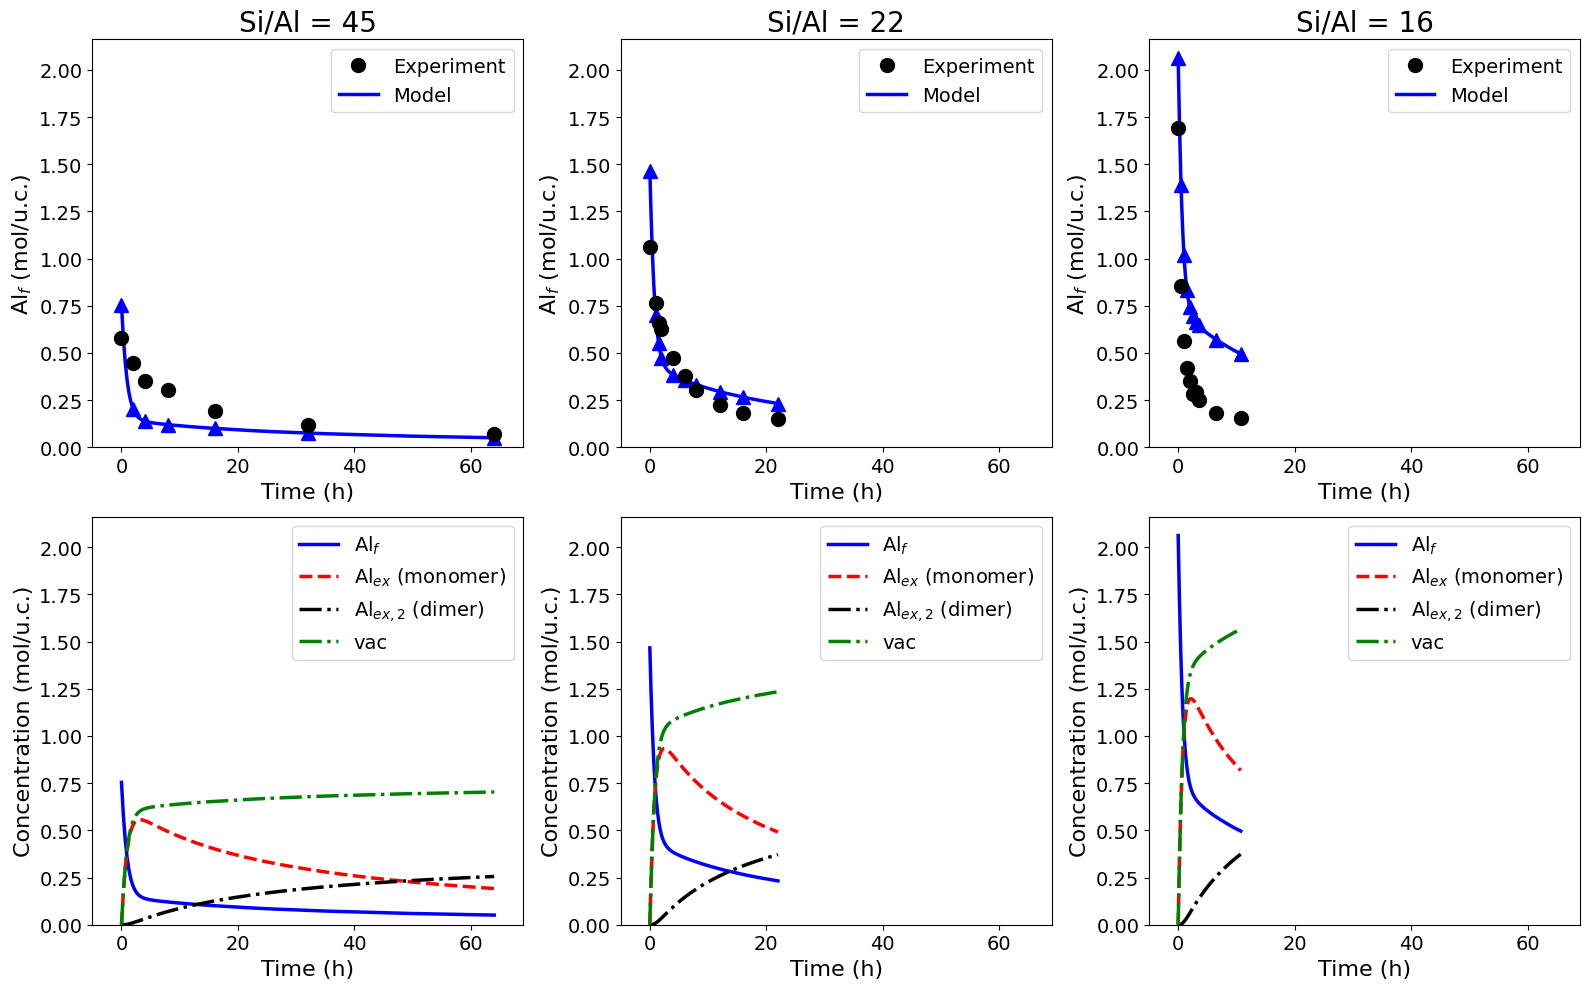

MAPE: 64.88%


In [19]:
# Visualize fits
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

model_prediction = {}
model_prediction['45']={}
model_prediction['22']={}
model_prediction['16']={}

aaaaa = 0
for idx, sial_ratio in enumerate(['45', '22', '16']):
    exp_data = data[sial_ratio]
    t = exp_data['time']
    Al_f_exp = exp_data['Al_f']
    Al_f0 = exp_data['Al_tot']
    
    # Fine time grid
    t_fine = np.linspace(0, t[-1], 200)
    y0 = [Al_f0, 0.0, 0.0, 0.0]
    solution = solve_ivp(
        fun=model,  # Change model # depening on the situation
        t_span=(min(t_fine), max(t_fine)), # Interval of integration (t0, tf)
        y0=y0,               # initial concentrations
        args=(best_params,),      # Same arguments with kinetic_model
        t_eval = t_fine,  # Times at which to store the computed solution
        dense_output=True    # Whether to compute a continuous solution
    )
    Al_f_pred = solution.y[0]
    Al_ex_pred = solution.y[1]
    Al_ex2_pred = solution.y[2]
    model_prediction[sial_ratio]['time']=t_fine
    model_prediction[sial_ratio]['Al_f']=solution.y[0]
    model_prediction[sial_ratio]['Al_ex']=solution.y[1]
    model_prediction[sial_ratio]['Al_ex,2']=solution.y[2]
    model_prediction[sial_ratio]['vac']=solution.y[3]
    
    alf_pred = simulate_model(best_params, sial_ratio)[0]
    # abs_frac_errors.append(np.abs(alf_pred - Al_f_exp) / denom)
    # abs_frac_errors = np.array(abs_frac_errors)
    aaaaa += mape_eps(Al_f_exp,alf_pred)
    
    
    # Top row: Al_f fit
    ax = axes[0, idx]
    ax.plot(t, Al_f_exp, 'o', markersize=10, label='Experiment', color='black', zorder=5)
    ax.plot(t_fine, Al_f_pred, '-', linewidth=2.5, label='Model', color='blue')
    ax.plot(t, alf_pred, '^', markersize=10, color='blue')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Al$_f$ (mol/u.c.)', fontsize=16)
    ax.set_title(f'Si/Al = {sial_ratio}', fontsize=20)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
    
    # Bottom row: Species evolution
    ax = axes[1, idx]
    ax.plot(t_fine, solution.y[0], '-', linewidth=2.5, label='Al$_f$', color='blue')
    ax.plot(t_fine, solution.y[1], '--', linewidth=2.5, label='Al$_{ex}$ (monomer)', color='red')
    ax.plot(t_fine, solution.y[2], '-.', linewidth=2.5, label='Al$_{ex,2}$ (dimer)', color='black')
    ax.plot(t_fine, solution.y[3], '-.', linewidth=2.5, label='vac', color='green')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Concentration (mol/u.c.)', fontsize=16)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

print(f'MAPE: {aaaaa/3:.2f}%')

# Check Mole Balances: $[Al_{tot}]=[Al_f]+[Al_{ex}]+2*[Al_{ex,2}]$

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, sial_ratio in enumerate(['45', '22', '16']):
    total = model_prediction[sial_ratio]['Al_f']+model_prediction[sial_ratio]['Al_ex']+2*model_prediction[sial_ratio]['Al_ex,2']
    ax = axes[idx]
    ax.plot(model_prediction[sial_ratio]['time'], total, '-', linewidth=2.5, label='Al$_f$', color='blue')
    ax.axhline(y=data[sial_ratio]['Al_tot'], color='r', linestyle='--', label='Threshold')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Concentration (mol/u.c.)', fontsize=16)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

# SCatter plots of (i) $k_1$ vs. $k_{-1}$, (ii) $k_1$ vs. $k_2$, (iii) $k_{-1}$ vs. $k_2$

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

thr = np.quantile(history['y'], 0.10)                  # 10th percentile (small y)
mask = history['y'] <= thr
y_cut = history['y'][mask]
X_cut = history['X'][mask]

# k1 vs k_1 colored by objective
ax_k1k_1 = axes[0]
sc = ax_k1k_1.scatter(10**X_cut[:, 0], 10**X_cut[:, 1], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k_1.scatter(best_params[0], best_params[1],
                  color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k_1.set_xscale('log'); ax_k1k_1.set_yscale('log')
ax_k1k_1.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
ax_k1k_1.set_ylabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc, ax=ax_k1k_1, label='log₁₀(objective)')
ax_k1k_1.legend(fontsize=9)

# k1 vs k2
ax_k1k2 = axes[1]
sc2 = ax_k1k2.scatter(10**X_cut[:, 0], 10**X_cut[:, 2], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k2.scatter(best_params[0], best_params[2],
                 color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k2.set_xscale('log'); ax_k1k2.set_yscale('log')
ax_k1k2.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
ax_k1k2.set_ylabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc2, ax=ax_k1k2, label='log₁₀(objective)')
ax_k1k2.legend(fontsize=9)

# k_1 vs k2
ax_k1k2 = axes[2]
sc2 = ax_k1k2.scatter(10**X_cut[:, 1], 10**X_cut[:, 2], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
ax_k1k2.scatter(best_params[0], best_params[2],
                 color='red', s=200, marker='*', zorder=10, label='Optimal')
ax_k1k2.set_xscale('log'); ax_k1k2.set_yscale('log')
ax_k1k2.set_xlabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
ax_k1k2.set_ylabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.colorbar(sc2, ax=ax_k1k2, label='log₁₀(objective)')
ax_k1k2.legend(fontsize=9)

In [ ]:
plt.contourf(X, Y, Z)
plt.scatter(10**X_cut[:, 0], 10**X_cut[:, 1], c=np.log10(y_cut),
                       cmap='turbo', s=30, alpha=0.7, edgecolors='none')
plt.scatter(best_params[0], best_params[1],
                  color='red', s=200, marker='*', zorder=10, label='Optimal')
plt.xscale('log'); ax_k1k_1.set_yscale('log')
plt.xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
plt.ylabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
plt.xscale('log')
plt.yscale('log')

In [ ]:
param_names = ['k1', 'k_1', 'k2']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ylim = 0
for pidx in range(3):
    ax_gp = axes[pidx]

    # Fix other params at optimum, sweep this one
    log_opt = np.log10(best_params)
    n_sweep = 80
    log_sweep = np.linspace(LOG_BOUNDS[pidx, 0], LOG_BOUNDS[pidx, 1], n_sweep)
    X_sweep = np.tile(log_opt, (n_sweep, 1))
    X_sweep[:, pidx] = log_sweep

    mu_gp, std_gp = gp.predict(X_sweep, return_std=True)

    ax_gp.plot(10**log_sweep, mu_gp, color='#E91E63', lw=2, label='GP mean')
    ax_gp.fill_between(10**log_sweep,
                        mu_gp - 2*std_gp, mu_gp + 2*std_gp,
                        alpha=0.25, color='#E91E63', label='GP ±2σ')
    ax_gp.axvline(best_params[pidx], color='black', ls='--', lw=1.5,
                  label=f'Optimal {param_names[pidx]}')
    print(best_params[pidx])
    ax_gp.set_xscale('log')
    if pidx == 0:
        ax_gp.set_xlabel(r'$k_1$ $h^{-1}$', fontsize=14)
    elif pidx == 1:
        ax_gp.set_xlabel(r'$k_{-1}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
    elif pidx == 2:
        ax_gp.set_xlabel(r'$k_{2}$ $(mol/u.c.)^{-1}h^{-1}$', fontsize=14)
    if max(mu_gp+2*std_gp) > ylim:
        ylim = max(mu_gp+2*std_gp)
    ax_gp.set_ylabel('Predicted objective', fontsize=14)
    ax_gp.set_ylim(0,ylim+2)
    ax_gp.legend(fontsize=13)
    ax_gp.grid(alpha=0.3)

In [ ]:
import numpy as np
from scipy.stats import norm

def get_credible_interval(gp, best_params, bounds, solve_ivp_func,
                           t_eval, n_samples=500, ci=95):
    # ── Step 1: Sample candidate parameter sets ──────────
    # Sample broadly in log10 space across the search bounds
    n_candidates = n_samples * 50   # oversample, then weight
    candidates = np.column_stack([
        np.random.uniform(lo, hi, n_candidates)
        for (lo, hi) in bounds
    ])
    # Convert log10 → real scale for GP query
    # (assuming your GP was trained on log10-transformed X)
    
    # ── Step 2: Query GP posterior at all candidates ──────
    mu, sigma = gp.predict(candidates, return_std=True)
    
    # ── Step 3: Compute weights from GP posterior ─────────
    # Treat GP mean as negative log-likelihood proxy:
    # lower predicted objective → higher weight
    # Temperature τ controls how sharply we focus near the minimum
    tau = np.std(mu) * 0.5          # adaptive temperature
    log_weights = -mu / tau
    log_weights -= log_weights.max()  # numerical stability
    weights = np.exp(log_weights)
    weights /= weights.sum()          # normalize to probability

    # ── Step 4: Sample parameter sets using weights ───────
    chosen_idx = np.random.choice(
        n_candidates, size=n_samples, replace=True, p=weights
    )
    sampled_log_params = candidates[chosen_idx]           # log10 scale
    sampled_params = 10 ** sampled_log_params             # real scale

    # ── Step 5: Propagate each parameter set through ODE ──
    al_curves = []
    failed = 0
    for params in sampled_params:
        try:
            al_f = solve_ivp_func(params, t_eval)
            if al_f is not None and len(al_f) == len(t_eval):
                al_curves.append(al_f)
        except Exception:
            failed += 1

    print(f"Successful ODE solves: {len(al_curves)}/{n_samples} "
          f"({failed} failed)")

    al_curves = np.array(al_curves)   # shape: (n_successful, len(t_eval))

    # ── Step 6: Compute credible interval ─────────────────
    lower_pct = (100 - ci) / 2        # 2.5 for 95% CI
    upper_pct = 100 - lower_pct       # 97.5 for 95% CI

    al_mean  = np.mean(al_curves, axis=0)
    al_lower = np.percentile(al_curves, lower_pct, axis=0)
    al_upper = np.percentile(al_curves, upper_pct, axis=0)

    return t_eval, al_mean, al_lower, al_upper

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
si_al_ratio = ['45', '22', '16']

for i, sial_ratio in enumerate(['45', '22', '16']):
    ax = axes[i]

    # ── Build t_eval for THIS dataset's time range ────────
    t_eval = np.linspace(0, data[sial_ratio]['time'][-1], 200)

    # ── Wrapper uses THIS dataset's t_exp and exp_data ────
    def solve_ivp_func(params, t_eval, idx=i):
        y0 = [data[sial_ratio]['Al_tot'], 0, 0, 0]
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(params,),
            t_eval=t_eval,
            method='Radau',
            rtol=1e-8,
            atol=1e-10
        )
        if not sol.success:
            return None
        return sol.y[0]   # Al_f row

    # ── Get CI for THIS dataset ────────────────────────────
    t, al_mean, al_lo, al_hi = get_credible_interval(
        gp=gp,
        best_params=best_params,
        bounds=[(0, 5), (0, 5), (0, 4)],
        solve_ivp_func=solve_ivp_func,
        t_eval=t_eval,
        n_samples=500
    )

    # ── Best-fit curve for THIS dataset ───────────────────
    al_best = solve_ivp_func(best_params, t_eval)
    alf_pred = simulate_model(best_params, sial_ratio)[0]
    # ── Plot ───────────────────────────────────────────────
    ax.fill_between(t, al_lo, al_hi,
                    alpha=0.25, color='teal',
                    label='95% credible interval')
    ax.plot(data[sial_ratio]['time'], alf_pred, '^', markersize=10, color='blue')
    ax.plot(t, al_mean, '--', color='teal',label='Posterior mean')
    ax.plot(t, al_best, '-', linewidth=2.5, label='Model', color='blue')
    ax.plot(data[sial_ratio]['time'], data[sial_ratio]['Al_f'], 'o', markersize=10, label='Experiment', color='black')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Al$_f$ (mol/u.c.)', fontsize=16)
    ax.set_title(f'Si/Al = {sial_ratio}', fontsize=20)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
si_al_ratio = ['45', '22', '16']

for i, sial_ratio in enumerate(['45', '22', '16']):
    ax = axes[i]

    # ── Build t_eval for THIS dataset's time range ────────
    t_eval = np.linspace(0, data[sial_ratio]['time'][-1], 200)

    # ── Wrapper uses THIS dataset's t_exp and exp_data ────
    def solve_ivp_func(params, t_eval, idx=i):
        y0 = [data[sial_ratio]['Al_tot'], 0, 0, 0]
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(params,),
            t_eval=t_eval,
            method='Radau',
            rtol=1e-8,
            atol=1e-10
        )
        if not sol.success:
            return None
        return sol.y[0]   # Al_f row

    # ── Get CI for THIS dataset ────────────────────────────
    t, al_mean, al_lo, al_hi = get_credible_interval(
        gp=gp,
        best_params=best_params,
        bounds=[(0, 5), (0, 5), (0, 4)],
        solve_ivp_func=solve_ivp_func,
        t_eval=t_eval,
        n_samples=500,
        ci=60
    )

    # ── Best-fit curve for THIS dataset ───────────────────
    al_best = solve_ivp_func(best_params, t_eval)
    alf_pred = simulate_model(best_params, sial_ratio)[0]
    # ── Plot ───────────────────────────────────────────────
    ax.fill_between(t, al_lo, al_hi,
                    alpha=0.25, color='teal',
                    label='60% credible interval')
    ax.plot(data[sial_ratio]['time'], alf_pred, '^', markersize=10, color='blue')
    ax.plot(t, al_mean, '--', color='teal',label='Posterior mean')
    ax.plot(t, al_best, '-', linewidth=2.5, label='Model', color='blue')
    ax.plot(data[sial_ratio]['time'], data[sial_ratio]['Al_f'], 'o', markersize=10, label='Experiment', color='black')
    ax.set_xlim(-5,data['45']['time'][-1]+5)
    ax.set_ylim(0,data['16']['Al_tot']+0.1)
    ax.set_xlabel('Time (h)', fontsize=16)
    ax.set_ylabel('Al$_f$ (mol/u.c.)', fontsize=16)
    ax.set_title(f'Si/Al = {sial_ratio}', fontsize=20)
    ax.tick_params(axis='x', labelsize=14, labelcolor='black')
    ax.tick_params(axis='y', labelsize=14, labelcolor='black')
    ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

# Test with different random seeds

In [ ]:
seeds = [42, 123, 7, 999, 314]
results = []
for s in seeds:
    params, history, gp = bayesian_optimize(seed=s, n_init=200, n_iter=300, disp=False)
    results.append((params, history['best_objective']))

In [ ]:
for i in range(len(results)):
    print(f'Rate constants: [{results[i][0][0]:8.3f}, '
          f'{results[i][0][1]:8.3f}, '
          f'{results[i][0][2]:8.3f}] '
          f'|K:{results[i][0][0]/results[i][0][1]:6.3f}'
          f'| objective: {results[i][1]:5.3f}')